In [35]:
# imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, HuberRegressor
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats.mstats import spearmanr
from itertools import product
from joblib import Parallel, delayed
from xgboost import XGBRegressor
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import torch.optim as optim
from ast import literal_eval
import warnings

warnings.filterwarnings(
    "ignore",
    message="Got `batch_size` less than 1 or larger than sample size.*",
    category=UserWarning,
    module="sklearn.neural_network._multilayer_perceptron"
)

np.random.seed(42)
torch.manual_seed(42)

In [36]:
# play around to create rolling window backtest, ensuring no data leakage

dl = DataLoad()
df = dl.load_dataset("model")

model.csv loaded succesfully


In [37]:
df = df.loc[:'2016-12-31']
features = [c for c in df.columns if c not in ["Ticker", "Target"]]
df_train = df[df.index <= "2015-12-31"]
X_train = df_train[features].to_numpy()
y_train = df_train["Target"].to_numpy()

In [38]:
# first of all will implement own scoring, not for training but for model evaluation
# as we will be creating weighted portfolios based on predictions both magnitude and direction are important
# so scoring will be a mix of both spearmen IC and directional accuracy
# DA is simply a sign check, when positive does model predict positive, when negative does model predict negative
# its a proportion between 0 - 1, therefore will subtract 0.5 and multiply by 2, to center it at 0 and be [-1,1]
# use IC instead of R^2 as its less sensitive to scale, will use spearmen as its less prone to outliers
# so scoring will be  0.6 * IC(spearmen) + 0.4 * DA(centered)
# Balanced Information & Directional Score (BIDS)

def bids(y_pred, y_true):

    rank_ic, _ = spearmanr(y_true,y_pred)
    if np.isnan(rank_ic):
        rank_ic = 0

    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    da_centered = 2 * (directional_accuracy - 0.5)

    return 0.6 * rank_ic + 0.4 * da_centered

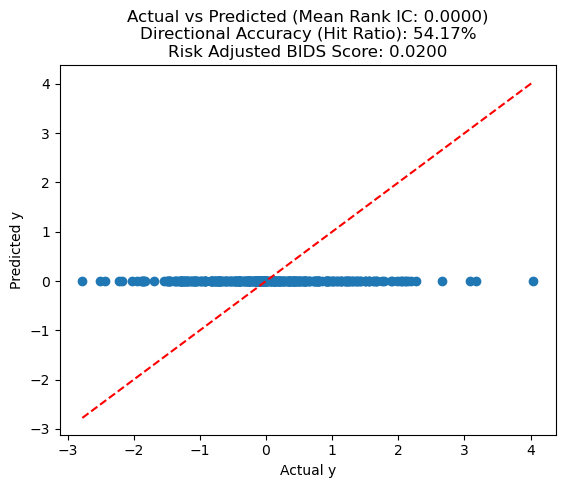

In [39]:
# as a baseline, predict the mean always
# setup a rolling walk forward evaluation for the evaluation set
# similar to how the real backtest will be

model = DummyRegressor(strategy="mean")

val_months = df[df.index > "2015-12-31"].index.unique().to_numpy()

y_preds = []
y_trues = []
for month in val_months:

    x_fit = df[df.index < month][features].to_numpy()
    y_fit = df[df.index < month]["Target"].to_numpy()
    model.fit(x_fit, y_fit)

    x_val = df[df.index == month][features].to_numpy()
    y_val = df[df.index == month]["Target"].to_numpy()
    y_preds.append(model.predict(x_val))
    y_trues.append(y_val)

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

                               feature  coefficient  non_zero
0              Semi-annual Log Returns    -0.039425      True
1                 Parkinson Volatility    -0.094857      True
2                     Volatility Ratio    -0.016661      True
3                            MA20/MA60    -0.078664      True
4                                VMA60    -0.043540      True
5                      Relative Volume     0.029934      True
6           Monthly Average True Range    -0.047386      True
7              10-day Efficiency Ratio     0.012191      True
8                            Body Down    -0.026599      True
9             Monthly Conviction Ratio     0.045246      True
10  Monthly Rogers-Satchell Volatility     0.066932      True
11            Volatility of Volatility    -0.050385      True
12                    Monthly Kurtosis     0.034696      True
13                  Entropy of Returns    -0.013172      True
14         Monthly Return Acceleration    -0.040199      True
15      

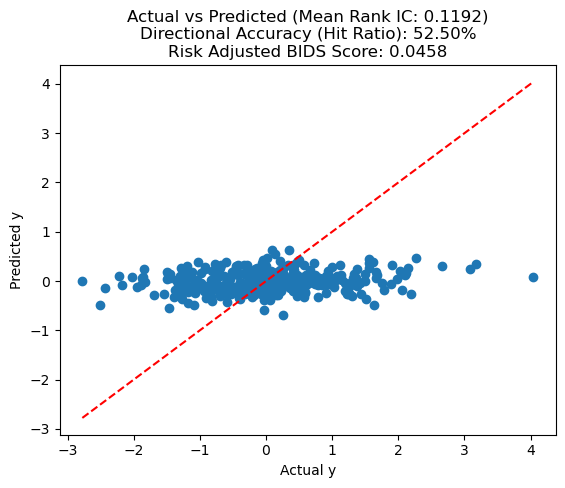

In [40]:
# try linear models

model = LinearRegression(n_jobs=-1)
model.fit(X_train,y_train)

coefs = model.coef_
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)


y_preds = []
y_trues = []
for month in val_months:

    x_fit = df[df.index < month][features].to_numpy()
    y_fit = df[df.index < month]["Target"].to_numpy()
    model.fit(x_fit, y_fit)

    x_val = df[df.index == month][features].to_numpy()
    y_val = df[df.index == month]["Target"].to_numpy()
    y_preds.append(model.predict(x_val))
    y_trues.append(y_val)

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [41]:
# create hyper parameter search, must create custom scaler + custom pipe + custom grid search
# sklearn default pipes and timeseries splits and grid search doesnt work with how my current dataset is created
# we dont have a "test" data so to speak, the prediction we test on (log returns of the next month) are part of the row of data we use to predict
# our predictions are dephased by 1 month
# expanding-window, one-step-ahead forecasting where the prediction is made on the latest available row (not the next row)
# sklearn packages would treat this last row as "test" data, which wouldnt be correct 

class RollingGridSearch():
    """
    Rolling-window grid search for time-series / expanding window prediction.
    """

    def __init__(self, model, param_grid, min_train_size=24, n_jobs=-1, verbose=1):

        self.model = model
        self.param_grid = param_grid
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_jobs = n_jobs
        self.verbose = verbose

    def _param_combinations(self):
        keys, values = list(self.param_grid.keys()), list(self.param_grid.values())
        for combo in product(*values):
            yield dict(zip(keys, combo))

    def _evaluate_params(self, params, X, y):
        scores = []
        model_step = clone(self.model)
        model_step.set_params(**params)

        for t in range(max(1, self.min_train_size), len(X)):

            X_prev = X[t-1]
            X_curr = X[t]

            n_prev = len(X_prev)

            X_train = X_curr[:n_prev]
            y_train = y[:n_prev]

            X_test = X_curr[n_prev:]
            y_test = y[n_prev:len(X_curr)]

            if len(X_test) == 0:
                continue

            model_step.fit(X_train, y_train)
            y_pred = model_step.predict(X_test)
            
            score = self.scorer_(y_pred, y_test)
            scores.append(score)

        mu = np.mean(scores)
        sigma = np.std(scores) + 1e-6
        score = mu * (mu / sigma) # Risk-Adjusted BIDS, will help find more stable parameters, instead of just the peak
        return {"params": params, "score": score}

    def fit(self, X, y):
        param_list = list(self._param_combinations())

        if self.verbose:
            print("Running grid search...")

        results = Parallel(n_jobs=self.n_jobs, prefer="threads")(
            delayed(self._evaluate_params)(params, X, y)
            for params in param_list
        )

        self.results_ = results
        best = max(results, key=lambda x: x["score"])
        self.best_params_ = best["params"]
        self.best_score_ = best["score"]

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        X_full = X[-1]

        self.best_model_ = clone(self.model)
        self.best_model_.set_params(**self.best_params_)
        self.best_model_.fit(X_full, y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)   



In [42]:
# for hpt only
X_train, y_train = dl.load_dataset("hpt","2015-12-31")
X_train = [np.ascontiguousarray(x) for x in X_train]
y_train = np.ascontiguousarray(y_train)

In [43]:
X_val, y_val = dl.load_dataset("hpt","2016-12-31")
X_val = [np.ascontiguousarray(x) for x in X_val]
y_val = np.ascontiguousarray(y_val)

Best Alpha: {'alpha': np.float64(0.01)}
Best Score: 0.00970688944781921
28 de 36
Index(['Semi-annual Log Returns', 'Parkinson Volatility', 'Volatility Ratio',
       'MA20/MA60', 'VMA60', 'Relative Volume', 'Monthly Average True Range',
       '10-day Efficiency Ratio', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Monthly Kurtosis',
       'Monthly Return Acceleration', 'Trend Strength',
       'Quarterly Hurst Exponent', '5-day RSI Slope', 'ADX Proxy', 'Gap Up',
       'Gap vs Intraday Move', 'Cumulative Volume Trend',
       'Price Volume Correlation', 'MA 20 Beta', 'Monthly Alpha', 'MA60 Alpha',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity_21d',
       'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
                               feature  coefficient  non_zero
0              Semi-annual Log Returns    -0.009190      True
1                 Parkinson Volatility    -0.070198      True
2                     Volatility Ratio    -0.

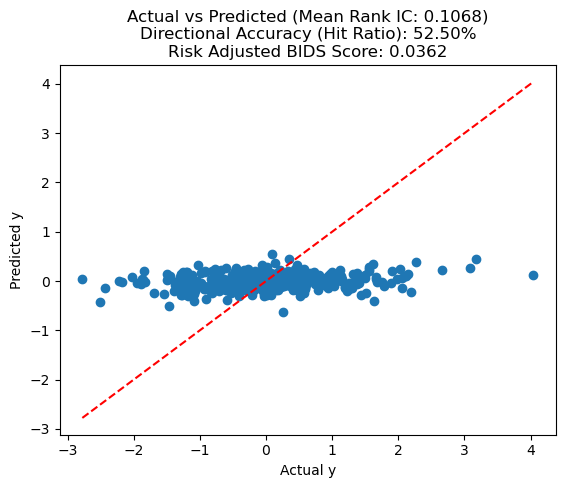

In [44]:
param_grid = {'alpha': np.logspace(-4,-1,10)}
grid = RollingGridSearch(Lasso(max_iter=1000, tol=1e-4, selection="random"), param_grid, min_train_size=12,verbose=0)
grid.fit(X_train, y_train)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

Best Alpha: {'alpha': np.float64(143.8449888287663)}
Best Score: 0.007183727951773227
36 de 36
Index(['Semi-annual Log Returns', 'Parkinson Volatility', 'Volatility Ratio',
       'MA20/MA60', 'VMA60', 'Relative Volume', 'Monthly Average True Range',
       '10-day Efficiency Ratio', 'Body Down', 'Monthly Conviction Ratio',
       'Monthly Rogers-Satchell Volatility', 'Volatility of Volatility',
       'Monthly Kurtosis', 'Entropy of Returns', 'Monthly Return Acceleration',
       'Trend Strength', 'Monthly Hurst Exponent', 'Quarterly Hurst Exponent',
       '5-day RSI Slope', 'ADX Proxy', 'Gap Up', 'Gap vs Intraday Move',
       'Cumulative Volume Trend', 'Price Volume Correlation',
       'Monthly Intraday Intensity', 'Zscore Volume', 'MA 20 Beta',
       'MA 63 Beta', 'MA 126 Beta', 'Monthly Alpha', 'MA60 Alpha',
       'Monthly Alpha Volatility', 'Semi-annual Alpha Volatility',
       'Amihud_Illiquidity_21d', 'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
             

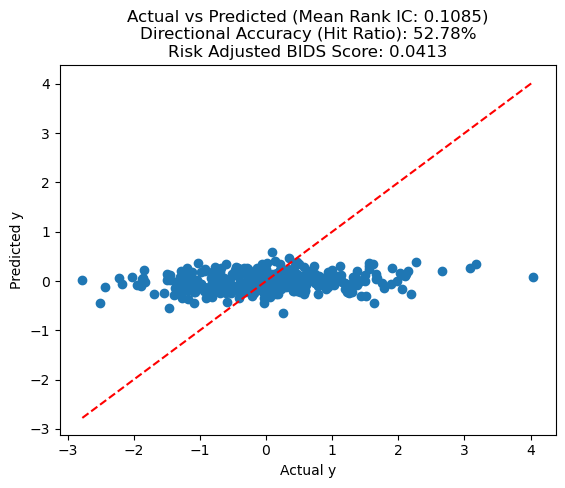

In [45]:
param_grid = {'alpha': np.logspace(-1, 5, 20)}
grid = RollingGridSearch(Ridge(max_iter=1000,tol=1e-4,solver="cholesky"), param_grid, min_train_size=12,verbose=0)

grid.fit(X_train, y_train)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

Best Params: {'alpha': np.float64(0.0379269019073225), 'l1_ratio': np.float64(0.30000000000000004)}
Best Score: 0.011549356263934303
25 de 36
Index(['Semi-annual Log Returns', 'Parkinson Volatility', 'Volatility Ratio',
       'VMA60', 'Relative Volume', 'Monthly Average True Range',
       '10-day Efficiency Ratio', 'Body Down', 'Monthly Conviction Ratio',
       'Monthly Kurtosis', 'Monthly Return Acceleration', 'Trend Strength',
       'Quarterly Hurst Exponent', '5-day RSI Slope', 'ADX Proxy', 'Gap Up',
       'Gap vs Intraday Move', 'Cumulative Volume Trend',
       'Price Volume Correlation', 'MA 20 Beta', 'MA60 Alpha',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity_21d',
       'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
                               feature  coefficient  non_zero
0              Semi-annual Log Returns    -0.003305      True
1                 Parkinson Volatility    -0.062584      True
2                     Volatility Ratio    -0.0189

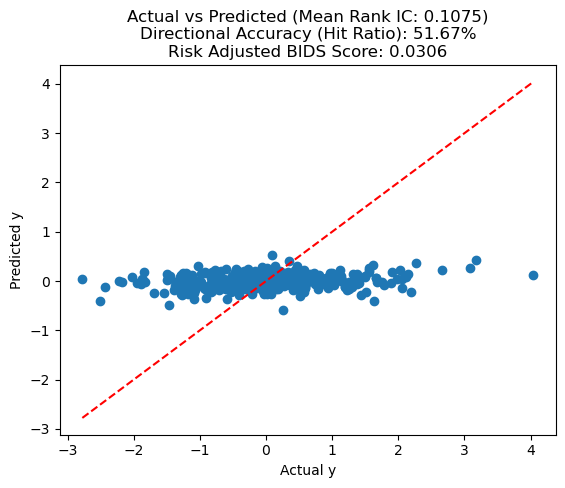

In [46]:
param_grid = {
    'alpha': np.logspace(-4,3, 20),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}
grid = RollingGridSearch(ElasticNet(max_iter=1000,tol=1e-4), param_grid, min_train_size=12,verbose=0)

grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [15]:
class RollingOptunaSearch():

    def __init__(self, model_builder, min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.SuccessiveHalvingPruner(min_resource=2, reduction_factor=3, min_early_stopping_rate=0)

    def _build_objective(self, Xs, y, lens):

        scorer = self.scorer_

        def objective(trial):

            model_base = self.model_builder(trial)

            scores = []

            for i, (train_len, t) in enumerate(lens):

                if len(Xs[t]) <= train_len: 
                    continue

                model_base.fit(Xs[t][:train_len], y[:train_len])
                y_pred = model_base.predict(Xs[t][train_len:])
                score = scorer(y_pred, y[train_len:len(Xs[t])])
                scores.append(score)
                current_mean = np.mean(scores)

                trial.report(current_mean, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
            
            mu = np.mean(scores)
            sigma = np.std(scores) + 1e-6

            # Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
            return mu * (mu / sigma)
        
        return objective

    def fit(self, X, y):

        start_t = max(1, self.min_train_size)
        lens = [(len(X[t-1]), t) for t in range(start_t, len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        optuna_jobs = 1 if self.parallel_windows else -1

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials,n_jobs=optuna_jobs)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        self.completed_trials = sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in study.trials)
        self.pruned_trials = sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials)

        if self.verbose:
            print(f"Trials: {len(study.trials)} total, {self.completed_trials} complete, {self.pruned_trials} pruned")
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_))
        self.best_model_.fit(X[-1], y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-16 17:15:56,145] A new study created in memory with name: no-name-5babd0d4-b49c-4096-9d81-7aea88202fa3
[I 2026-05-16 17:16:00,380] Trial 3 pruned. 
[I 2026-05-16 17:16:00,630] Trial 17 pruned. 
[I 2026-05-16 17:16:01,275] Trial 16 pruned. 
[I 2026-05-16 17:16:01,757] Trial 0 pruned. 
[I 2026-05-16 17:16:03,350] Trial 4 pruned. 
[I 2026-05-16 17:16:03,608] Trial 1 pruned. 
[I 2026-05-16 17:16:04,589] Trial 11 pruned. 
[I 2026-05-16 17:16:04,715] Trial 14 pruned. 
[I 2026-05-16 17:16:06,372] Trial 6 pruned. 
[I 2026-05-16 17:16:06,819] Trial 5 pruned. 
[I 2026-05-16 17:16:07,048] Trial 22 pruned. 
[I 2026-05-16 17:16:07,220] Trial 25 pruned. 
[I 2026-05-16 17:16:07,491] Trial 10 pruned. 
[I 2026-05-16 17:16:07,836] Trial 12 pruned. 
[I 2026-05-16 17:16:08,131] Tr

Trials: 220 total, 18 complete, 202 pruned
Best Params: {'n_estimators': 319, 'max_depth': 12, 'max_features': 0.6603133019285621, 'min_samples_leaf': 4, 'min_samples_split': 8}
Best Score: 0.008461002115549041
36 de 36
Index(['Semi-annual Log Returns', 'Parkinson Volatility', 'MA20',
       'Distance from MA20', 'VMA60', 'Relative Volume', 'Volume Flow Ratio',
       'Gains', '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Monthly Skewness', 'Return Autocorr 5D',
       'Monthly Return Acceleration', 'High Low Trend Position',
       'Monthly Hurst Exponent', '5-day RSI Slope', 'ADX Proxy',
       'Gap Direction', 'Gap Persistence', 'Dollar Volume',
       'Monthly Intraday Intensity', '63 Day Beta', 'MA 20 Beta', 'MA 63 Beta',
       'MA 126 Beta', 'Monthly Alpha', 'MA60 Alpha',
       'Monthly Alpha Volatility', 'Semi-annual Alpha Volatility',
       'Amihud_Illiquidity', 'Amihud_Il

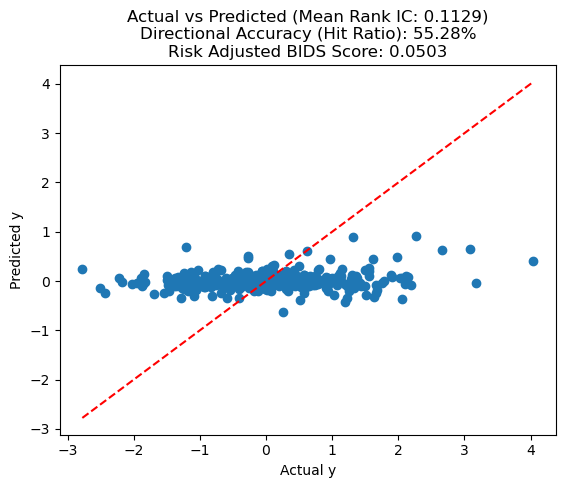

In [12]:
#random forest - OPTIMIZED search space (balanced exploration)

def rf_builder(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 350),
        max_depth=trial.suggest_int("max_depth", 4, 12),
        max_features=trial.suggest_float("max_features", 0.6, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 8),
        min_samples_split=trial.suggest_int("min_samples_split", 4, 8),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(
    rf_builder,
    min_train_size=12,
    n_trials=220,
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=2, reduction_factor=3, min_early_stopping_rate=0),
    verbose=0
)

grid.fit(X_train, y_train)

random_forest_model = grid.best_model_

print(f"Trials: {len(grid.study_.trials)} total, {grid.completed_trials} complete, {grid.pruned_trials} pruned")
print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = df[features].columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

model = random_forest_model

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

[I 2026-05-16 17:25:01,356] A new study created in memory with name: no-name-16aa4f24-28a6-4503-a75d-5b486213739e
[I 2026-05-16 17:25:07,338] Trial 2 pruned. 
[I 2026-05-16 17:25:07,422] Trial 6 pruned. 
[I 2026-05-16 17:25:08,388] Trial 8 pruned. 
[I 2026-05-16 17:25:08,575] Trial 12 pruned. 
[I 2026-05-16 17:25:09,211] Trial 3 pruned. 
[I 2026-05-16 17:25:09,777] Trial 4 pruned. 
[I 2026-05-16 17:25:10,889] Trial 1 pruned. 
[I 2026-05-16 17:25:11,198] Trial 14 pruned. 
[I 2026-05-16 17:25:11,820] Trial 23 pruned. 
[I 2026-05-16 17:25:12,770] Trial 20 pruned. 
[I 2026-05-16 17:25:13,139] Trial 17 pruned. 
[I 2026-05-16 17:25:13,288] Trial 18 pruned. 
[I 2026-05-16 17:25:13,731] Trial 21 pruned. 
[I 2026-05-16 17:25:13,754] Trial 5 pruned. 
[I 2026-05-16 17:25:15,763] Trial 25 pruned. 
[I 2026-05-16 17:25:16,094] Trial 15 pruned. 
[I 2026-05-16 17:25:16,667] Trial 7 pruned. 
[I 2026-05-16 17:25:17,568] Trial 22 pruned. 
[I 2026-05-16 17:25:17,688] Trial 16 pruned. 
[I 2026-05-16 17:25:

Trials: 260 total, 15 complete, 245 pruned
Best Params: {'n_estimators': 890, 'max_depth': 8, 'learning_rate': 0.056772030194577716, 'min_child_weight': 1.2302414602549787, 'gamma': 0.07793029915029376, 'reg_alpha': 0.015761687679292105, 'reg_lambda': 0.9000758775886458, 'subsample': 0.8403061936998724, 'colsample_bytree': 0.7094481478298664}
Best Score: 0.013843287812812183
36 de 36
Index(['Semi-annual Log Returns', 'Parkinson Volatility', 'MA20',
       'Distance from MA20', 'VMA60', 'Relative Volume', 'Volume Flow Ratio',
       'Gains', '10-day Efficiency Ratio', 'Monthly Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Monthly Skewness', 'Return Autocorr 5D',
       'Monthly Return Acceleration', 'High Low Trend Position',
       'Monthly Hurst Exponent', '5-day RSI Slope', 'ADX Proxy',
       'Gap Direction', 'Gap Persistence', 'Dollar Volume',
       'Monthly Intraday Intensity', '63 Day Beta', 'MA 20 Beta', 'MA 63

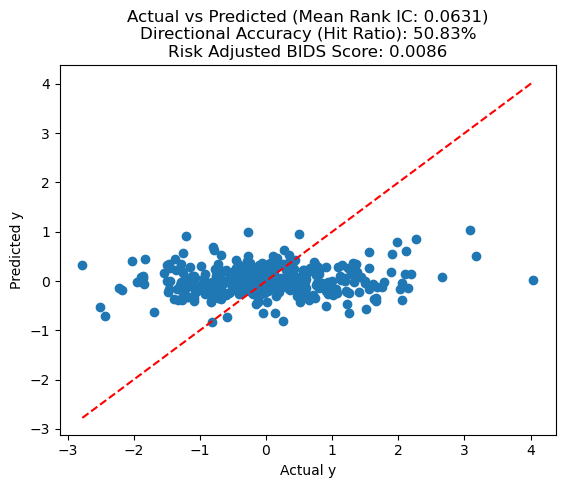

In [13]:
# XGBoost - OPTIMIZED search space (tighter to prevent overfitting)

def xg_builder(trial):
    return XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 150, 1200),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        min_child_weight=trial.suggest_float("min_child_weight", 0.8, 1.5, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 0.1),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-5, 0.05, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 0.8, 3.0, log=True),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(
    xg_builder,
    min_train_size=12,
    n_trials=260,
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=2, reduction_factor=3, min_early_stopping_rate=0),
    sampler=optuna.samplers.TPESampler(seed=42),
    verbose=0
)

grid.fit(X_train, y_train)
xgboost_model = grid.best_model_

print(f"Trials: {len(grid.study_.trials)} total, {grid.completed_trials} complete, {grid.pruned_trials} pruned")
print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = df[features].columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

model = xgboost_model

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-16 17:30:13,137] A new study created in memory with name: no-name-2d2e2584-b48b-43c6-b68b-70decf0e786c
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (273) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (309) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

Trials: 150 total, 21 complete, 129 pruned
Best Params: {'hidden_layer_sizes': '(64,)', 'alpha': 0.05382057918731984, 'learning_rate_init': 0.00010157627435820952, 'learning_rate': 'adaptive', 'batch_size': 128, 'activation': 'relu', 'max_iter': 242}
Best Score: 0.015362921906206145


/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (242) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (242) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (242) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (242) reached and the optimization hasn't converged yet.
  warnings.warn(
/hom

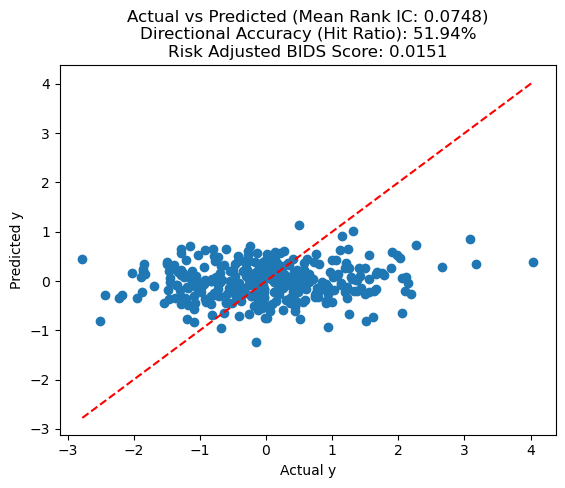

In [14]:
# MLP - OPTIMIZED search space (tighter architecture)

def mlp_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["(32,)","(64,)","(32, 16)","(64, 32)","(64, 64)"])

    return MLPRegressor(
        hidden_layer_sizes=literal_eval(hidden),
        alpha=trial.suggest_float("alpha", 1e-5, 0.1, log=True),
        learning_rate_init=trial.suggest_float("learning_rate_init", 1e-4, 1e-3, log=True),
        learning_rate=trial.suggest_categorical("learning_rate", ['constant', 'adaptive']),
        batch_size=trial.suggest_categorical("batch_size", [64, 128]),
        activation=trial.suggest_categorical("activation", ['relu']),
        max_iter=trial.suggest_int("max_iter", 200, 400),
        solver='adam',
        early_stopping=False,
        random_state=42
    )

grid = RollingOptunaSearch(
    mlp_builder,
    min_train_size=12,
    n_trials=150,
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=2, reduction_factor=3, min_early_stopping_rate=0),
    sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
    verbose=0
)

grid.fit(X_train, y_train)
print(f"Trials: {len(grid.study_.trials)} total, {grid.completed_trials} complete, {grid.pruned_trials} pruned")
print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

Best Ensemble Weight: 0.600 (RF vs XGB)
Best Ensemble Score: 0.019254


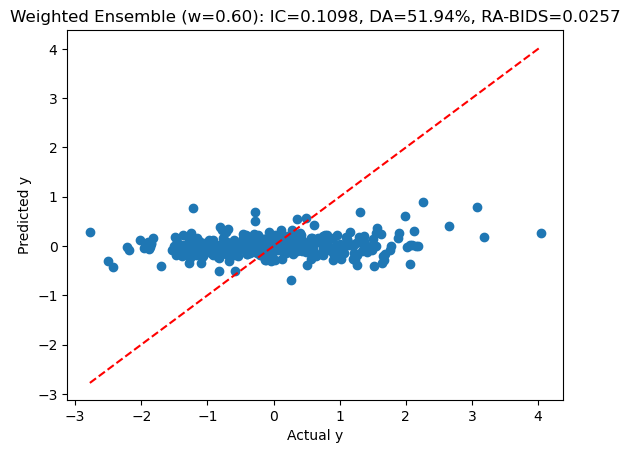

In [15]:
# Weighted ensemble optimization - optimize blend of RF and XGB

def ensemble_builder(trial):
    class WeightedEnsembleWrapper:
        def __init__(self, rf_model, xgb_model, weight):
            self.rf = rf_model
            self.xgb = xgb_model
            self.weight = weight
        
        def predict(self, X):
            rf_pred = self.rf.predict(X)
            xgb_pred = self.xgb.predict(X)
            return self.weight * rf_pred + (1 - self.weight) * xgb_pred
    
    weight = trial.suggest_float("ensemble_weight", 0.0, 1.0)
    return WeightedEnsembleWrapper(random_forest_model, xgboost_model, weight)

# Grid search for optimal weight
class EnsembleSearch:
    def __init__(self, builder, n_trials=30):
        self.builder = builder
        self.n_trials = n_trials
    
    def fit(self, X, y):
        best_score = -np.inf
        best_weight = 0.5
        
        for trial_num in range(self.n_trials):
            weight = trial_num / (self.n_trials - 1) if self.n_trials > 1 else 0.5
            
            class FixedTrial:
                def suggest_float(self, name, low, high):
                    return weight
            
            model = self.builder(FixedTrial())
            
            scores = []
            for t in range(1, len(X)):
                X_prev = X[t-1]
                X_curr = X[t]
                n_prev = len(X_prev)
                
                model.rf.fit(X_prev, y[:n_prev])
                model.xgb.fit(X_prev, y[:n_prev])
                
                y_pred = model.predict(X_curr[n_prev:])
                y_t = y[n_prev:len(X_curr)]
                
                scores.append(bids(y_pred, y_t))
            
            mu = np.mean(scores)
            sigma = np.std(scores) + 1e-6
            score = mu * (mu / sigma)
            
            if score > best_score:
                best_score = score
                best_weight = weight
        
        self.best_weight = best_weight
        self.best_score = best_score
        self.best_model_ = self.builder(FixedTrial())
        self.best_model_.weight = best_weight
        
        return self

ensemble_search = EnsembleSearch(ensemble_builder, n_trials=21)
ensemble_search.fit(X_train, y_train)

print(f"Best Ensemble Weight: {ensemble_search.best_weight:.3f} (RF vs XGB)")
print(f"Best Ensemble Score: {ensemble_search.best_score:.6f}")

# Test on validation set
train_months = len(X_train)
y_preds = []
y_trues = []
for t in range(train_months, len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    random_forest_model.fit(X_prev, y_val[:n_prev])
    xgboost_model.fit(X_prev, y_val[:n_prev])
    
    rf_pred = random_forest_model.predict(X_curr[n_prev:])
    xgb_pred = xgboost_model.predict(X_curr[n_prev:])
    weighted_pred = ensemble_search.best_weight * rf_pred + (1 - ensemble_search.best_weight) * xgb_pred
    
    y_preds.append(weighted_pred)
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred, y_true)[0] for y_pred, y_true in zip(y_preds, y_trues)]
bids_scores = [bids(y_pred, y_true) for y_pred, y_true in zip(y_preds, y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Weighted Ensemble (w={ensemble_search.best_weight:.2f}): IC={np.mean(ics):.4f}, DA={sign_accuracy:.2%}, RA-BIDS={ra_bids:.4f}")
plt.show()

In [26]:
# try out simple mlp but with pytorch for gpu accelaration

class MLP(nn.Module):

    def __init__(self,input_size,hidden_layers,activation,lr,wd,dropout,batch_size):
        super().__init__()
        self.lr = lr
        self.wd = wd
        self.batch_size = batch_size
        layers = []
        in_features = input_size
        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }
        self.activation = activation
        
        use_dropout = dropout > 0

        for i,h in enumerate(hidden_layers):

            lin = nn.Linear(in_features,h)

            if activation == "relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='relu')
            elif activation == "leaky_relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='leaky_relu')
            else:
                nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)

            layers.append(lin)
            layers.append(activation_map[activation]())

            if use_dropout and i < len(hidden_layers) - 1:
                layers.append(nn.Dropout(dropout))

            in_features = h
        
        lin = nn.Linear(in_features,1)
        nn.init.xavier_uniform_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers.append(lin)

        self.model = nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x).squeeze(-1)

In [ ]:
# pytorch version of bids
def bids_torch(y_true, y_pred):
    def _rankdata_avg(x):
        x = x.contiguous().view(-1).to(dtype=torch.float64)
        n = x.size(0)
        vals, idx = torch.sort(x)
        _, counts = torch.unique_consecutive(vals, return_counts=True)
        counts = counts.to(device=vals.device)
        cumsum = torch.cumsum(counts, dim=0)
        starts = torch.cat((torch.tensor([0], device=vals.device, dtype=cumsum.dtype), cumsum[:-1]))
        ends = starts + counts - 1
        avg_ranks = (starts.to(dtype=torch.float64) + ends.to(dtype=torch.float64) + 2.0) / 2.0
        ranks_sorted = torch.repeat_interleave(avg_ranks, counts)
        ranks = torch.empty(n, dtype=torch.float64, device=vals.device)
        ranks[idx] = ranks_sorted
        return ranks

    t_rank = _rankdata_avg(y_true)
    p_rank = _rankdata_avg(y_pred)

    t_rank_c = t_rank - t_rank.mean()
    p_rank_c = p_rank - p_rank.mean()

    denom = t_rank_c.std(unbiased=False) * p_rank_c.std(unbiased=False)
    rank_ic = (t_rank_c * p_rank_c).mean() / denom

    if torch.isnan(rank_ic):
        rank_ic = torch.tensor(0.0, dtype=torch.float64, device=rank_ic.device)

    da_centered = 2 * ((torch.sign(y_true) == torch.sign(y_pred)).float().mean() - 0.5)
    da_centered = da_centered.to(dtype=torch.float64)

    return 0.6 * rank_ic + 0.4 * da_centered

In [28]:
def train_model(model,dataloaders,optimizer,criterion,epochs,verbose=0):
    if verbose:
        run_train_loss, run_val_loss, run_bids_score = [], [], []

    ema_bids = None
    max_bids = -np.inf
    alpha = 0.9

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,)

    for e in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in dataloaders["train"]:

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x),batch_y)
            loss.backward()
            optimizer.step()

            if verbose:
                train_loss += loss.item() * batch_y.size(0)               
        
        if "val" in dataloaders:
            model.eval()
            with torch.no_grad():

                preds = torch.cat([model(batch_x) for batch_x, _ in dataloaders["val"]])
                targets = torch.cat([batch_y for _, batch_y in dataloaders["val"]])

                current_bids = bids_torch(targets, preds).item()
                ema_bids = current_bids if ema_bids is None else (alpha * ema_bids) + ((1 - alpha) * current_bids)

                if ema_bids > max_bids:
                    max_bids = ema_bids
        
        scheduler.step()     
        
        if verbose:
            train_loss /= len(dataloaders["train"].dataset)  
            print(f"Epoch {e+1}/{epochs}.. ")
            print(f"Train loss: {train_loss:.6f}.. ")
            if "val" in dataloaders:
                val_loss = criterion(preds,targets).item()
                print(f"Validation Loss: {val_loss}")
                print(f"BIDS Score: {ema_bids}")
        
            run_train_loss.append(train_loss)
            if "val" in dataloaders:
                run_val_loss.append(val_loss)
                run_bids_score.append(ema_bids)
            
    
    if verbose:
        epochs_range = range(1, e+2)
        plt.plot(epochs_range, run_train_loss, label='Train Loss')
        if "val" in dataloaders:
            plt.plot(epochs_range,run_val_loss, label="Validation Loss")
            plt.plot(epochs_range,run_bids_score, label="BIDS EMA Score")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss')
        plt.show()

    
    return max_bids if "val" in dataloaders else model

In [29]:
def reset_weights(model, activation_type):

    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv1d, nn.Conv2d)):
            if activation_type in ["relu", "leaky_relu"]:
                nn.init.kaiming_uniform_(m.weight, nonlinearity=activation_type)
            else:
                nn.init.xavier_uniform_(m.weight)
            
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        
        elif isinstance(m, (nn.RNN, nn.LSTM, nn.GRU)):
            for name, param in m.named_parameters():
                if 'weight' in name:
                    nn.init.orthogonal_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)

In [ ]:
# create optuna search for pytorch

class RollingOptunaSearchPyTorch():

    def __init__(self, model_builder,device,min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.device = device
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

    def _build_objective(self, Xs, y, lens):


        def objective(trial):

            model = self.model_builder(trial).to(self.device)
            scores = []

            for i, (train_len,t) in enumerate(lens):

                if len(Xs[t]) <= train_len:
                    continue

                train_dataloader = DataLoader(TensorDataset(Xs[t][:train_len], y[:train_len]),batch_size=model.batch_size,shuffle=False)
                val_dataloader = DataLoader(TensorDataset(Xs[t][train_len:], y[train_len:len(Xs[t])]),batch_size=model.batch_size,shuffle=False)

                reset_weights(model,model.activation)

                score = train_model(model, {"train" : train_dataloader, "val" : val_dataloader},optim.AdamW(model.parameters(),lr=model.lr,weight_decay=model.wd),nn.MSELoss(),60,0)
                scores.append(score)

                current_mean = np.mean(scores)

                trial.report(current_mean, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
            
            mu = np.mean(scores)
            sigma = np.std(scores) + 1e-6

            # Check if mu is negative; if so, return mu to help Optuna move away from it
            # Otherwise, return the risk-adjusted score
            return mu * (mu / sigma) if mu > 0 else mu
        
        return objective

    def fit(self, X, y):

        start_t = max(1, self.min_train_size)
        lens = [(len(X[t-1]), t) for t in range(start_t, len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        self.completed_trials = sum(trial.state == optuna.trial.TrialState.COMPLETE for trial in study.trials)
        self.best_params_pruned_trials = sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials)

        if self.verbose:
            print(f"Trials: {len(study.trials)} total, {self.completed_trials} complete, {self.pruned_trials} pruned")
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_)).to(self.device)
        train_dataloader = DataLoader(TensorDataset(X[-1],y),batch_size=self.best_model_.batch_size,shuffle=False)
        self.best_model_ = train_model(self.best_model_,{"train": train_dataloader},optim.AdamW(self.best_model_.parameters(),lr=self.best_model_.lr,weight_decay=self.best_model_.wd),nn.MSELoss(),200,1)

        return self

    def predict(self, X):
        self.best_model_.eval()
        with torch.no_grad():
            return self.best_model_(X).cpu().numpy()    

In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = [torch.from_numpy(x).float().to(device, non_blocking=True) for x in X_train]
y_train = torch.from_numpy(y_train).float().to(device, non_blocking=True)
X_test = [torch.from_numpy(x).float().to(device, non_blocking=True) for x in X_val]
y_test = torch.from_numpy(y_val).float().to(device, non_blocking=True)
input_features = X_train[0].shape[1]

def mlp_pytorch_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[32]", "[64]", "[128]",
                                                              "[32, 16]", "[64, 32]", "[128, 64]"])
    return MLP(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-5, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(mlp_pytorch_builder, device,min_train_size=12, n_trials=120, verbose=0)
grid.fit(X_train, y_train)

print(f"Trials: {len(grid.study_.trials)} total, {grid.completed_trials} complete, {grid.pruned_trials} pruned")
print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_test)):
    X_prev = X_test[t-1]
    X_curr = X_test[t]
    n_prev = len(X_prev)
    reset_weights(model,model.activation)
    train_dataloader = DataLoader(TensorDataset(X_prev,y_test[:n_prev]),batch_size=model.batch_size,shuffle=False)
    model = train_model(model,{"train": train_dataloader},optim.AdamW(model.parameters(),lr=model.lr,weight_decay=model.wd),nn.MSELoss(),200,0)

    y_preds.append(model(X_curr[n_prev:]).cpu().numpy())
    y_trues.append(y_test[n_prev:len(X_curr)].cpu().numpy())

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]

y_pred = torch.cat(y_preds)
y_true = torch.cat(y_trues)

plt.scatter(y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.detach().cpu().numpy().min(), y_true.detach().cpu().numpy().max()], [y_true.detach().cpu().numpy().min(),y_true.detach().cpu().numpy().max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nMean BIDS Score: {np.mean(bids_scores):.4f}")
plt.show()

In [ ]:
def cnn_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[64, 32]", "[128, 64]",
                                                              "[64, 64]"])
    return CNN(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(cnn_builder, device,min_train_size=12, n_trials=120, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-08 14:28:05,056] A new study created in memory with name: no-name-c1b07397-154e-4d45-915a-dda3b514b76d
[I 2026-05-08 14:29:04,037] Trial 0 finished with value: 0.046745471320221804 and parameters: {'hidden_layer_sizes': '[64]', 'activation': 'tanh', 'lr': 0.00010994335574766199, 'wd': 0.07579479953348005, 'dropout': 0.45, 'batch_size': 512}. Best is trial 0 with value: 0.046745471320221804.
[I 2026-05-08 14:30:59,226] Trial 1 finished with value: 0.14445037490354215 and parameters: {'hidden_layer_sizes': '[128, 64, 32]', 'activation': 'tanh', 'lr': 0.0001238513729886094, 'wd': 0.0026926469100861782, 'dropout': 0.05, 'batch_size': 128}. Best is trial 1 with value: 0.14445037490354215.
[I 2026-05-08 14:33:50,801] Trial 2 finished with value: 0.18350968467644682 a

KeyboardInterrupt: 

In [ ]:
def lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[64, 32]", "[128, 64]",
                                                              "[64, 64]"])
    return LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(lstm_builder, device,min_train_size=12, n_trials=120, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
def cnn_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[64, 32]", "[128, 64]",
                                                              "[64, 64]"])
    return CNN(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(cnn_builder, device,min_train_size=12, n_trials=120, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# finally, RNN

def LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)


In [ ]:
def lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[64, 32]", "[128, 64]",
                                                              "[64, 64]"])
    return LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(lstm_builder, device,min_train_size=12, n_trials=120, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
#try a mix of cnn and lstm

def CNN_LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)

In [ ]:
def cnn_lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[64, 32]", "[128, 64]",
                                                              "[64, 64]"])
    return CNN_LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-3, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256]))

grid = RollingOptunaSearchPyTorch(cnn_lstm_builder, device,min_train_size=12, n_trials=120, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# transformer

Forget standard configs. Think:

Layers: 1–2
Heads: 1–2
Embedding dim: 16–32
FFN dim: 32–64

Anything bigger = overfitting machine.

A rough mental target:

<100k parameters total